# Showcase — the Horn of Africa drought (CHIRPS rainfall)

Between 2020 and 2023 the Horn of Africa endured its worst drought in over 40 years: **five consecutive rainy seasons failed**, and the 2022 season was the driest on record, contributing to an estimated 43,000 deaths in Somalia. **CHIRPS** (Climate Hazards Center) is the standard quasi-global rainfall dataset for drought monitoring; the earthlens **CHC** backend fetches it over anonymous FTP.

## What this notebook does

1. **Download CHIRPS monthly rainfall** for the March–May *long rains* of every year 2010–2023.
2. **Build a seasonal-rainfall time series** for the region and compare each year against the long-term average (a simple standardized anomaly, the basis of the SPI).
3. **Map** a normal season (2018) against the failed 2022 season and the deficit.

> Live CHIRPS FTP download — no credentials required (this cell takes a few minutes).

In [1]:
import os, tempfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
logger.disable("earthlens"); logger.disable("pyramids")

# --- Download CHIRPS Mar-May monthly rainfall per year and sum to a season total ---
from pyramids.dataset import Dataset
LAT, LON = [-5.0, 12.0], [38.0, 52.0]   # Horn of Africa (Somalia / Ethiopia / Kenya)

def mam_total(year):
    paths = EarthLens(
        data_source="chc", temporal_resolution="monthly", variables=["precipitation"],
        start=f"{year}-03-01", end=f"{year}-05-31", lat_lim=LAT, lon_lim=LON,
        path=tempfile.mkdtemp(),
    ).download(progress_bar=False)
    grids = [np.asarray(Dataset.read_file(str(p)).read_array(), dtype="float32") for p in paths]
    grids = [g[0] if g.ndim == 3 else g for g in grids]
    arr = np.where(np.array(grids) < 0, np.nan, grids)
    return np.nansum(arr, axis=0)    # mm summed over Mar+Apr+May

YEARS = list(range(2010, 2024))
seasons = {}
try:
    for y in YEARS:
        seasons[y] = mam_total(y)
    print(f"downloaded {len(seasons)} long-rains seasons (2010-2023)")
except Exception as exc:  # noqa: BLE001
    print("CHIRPS download skipped:", exc)

downloaded 14 long-rains seasons (2010-2023)


## Seasonal rainfall time series and standardized anomaly

Averaging each season over the region gives one rainfall total per year. Expressed as a standardized anomaly `(year − mean) / std` — the idea behind the SPI — the failed seasons stand out as strongly negative (drought) bars.

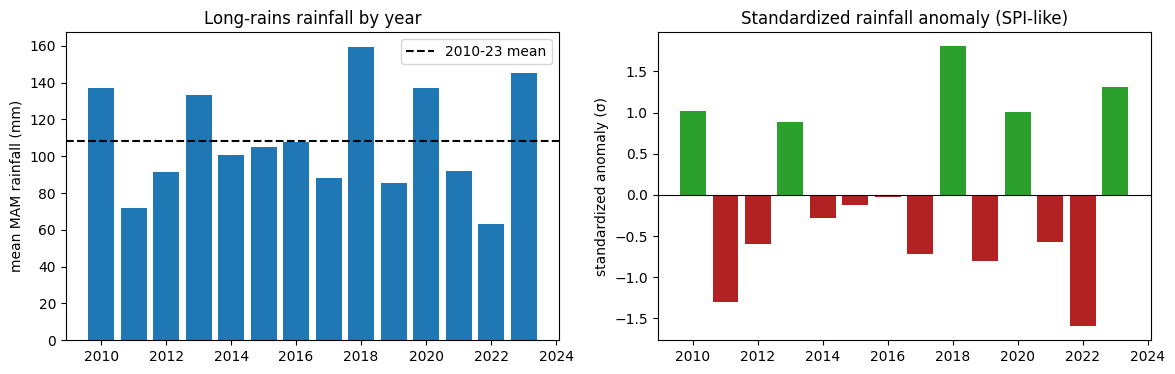

2021: 92 mm  (-0.6σ)
2022: 63 mm  (-1.6σ)


In [2]:
# Regional-mean seasonal rainfall, then a standardized anomaly (SPI-like z-score).
if seasons:
    yrs = sorted(seasons)
    totals = np.array([np.nanmean(seasons[y]) for y in yrs])
    z = (totals - totals.mean()) / totals.std()
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].bar(yrs, totals, color="tab:blue"); ax[0].axhline(totals.mean(), color="k", ls="--", label="2010-23 mean")
    ax[0].set(ylabel="mean MAM rainfall (mm)", title="Long-rains rainfall by year"); ax[0].legend()
    colors = ["firebrick" if v < 0 else "tab:green" for v in z]
    ax[1].bar(yrs, z, color=colors); ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set(ylabel="standardized anomaly (σ)", title="Standardized rainfall anomaly (SPI-like)")
    plt.show()
    for y in (2021, 2022):
        if y in seasons: print(f"{y}: {totals[yrs.index(y)]:.0f} mm  ({z[yrs.index(y)]:+.1f}σ)")

## Maps: a normal season vs the failed 2022 season

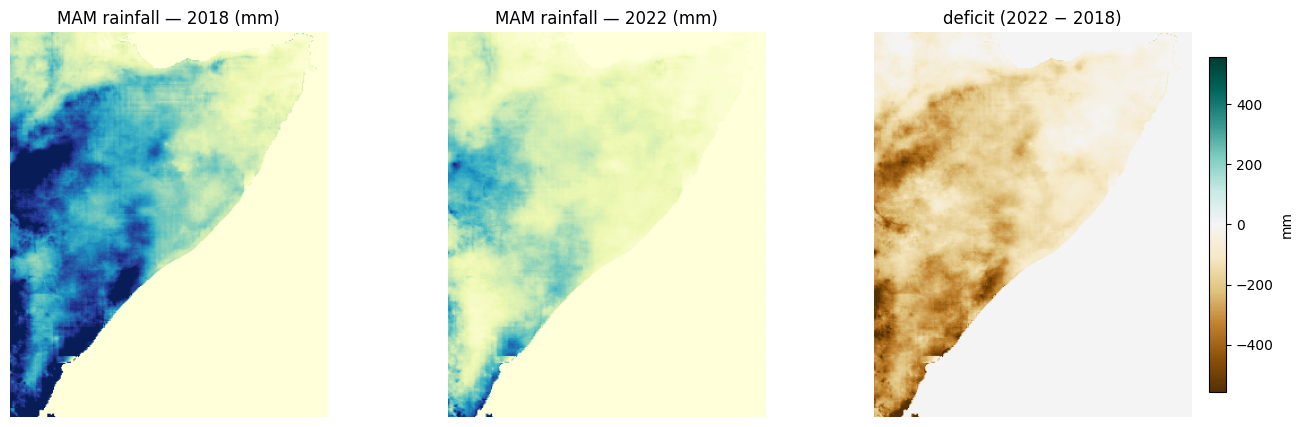

mean MAM rainfall  2018: 159 mm   2022: 63 mm   (-60%)


In [3]:
# 2018 (near-normal) vs 2022 (failed), and the per-pixel deficit.
if seasons and 2018 in seasons and 2022 in seasons:
    wet, dry = seasons[2018], seasons[2022]
    h, w = min(wet.shape[0], dry.shape[0]), min(wet.shape[1], dry.shape[1])
    wet, dry = wet[:h, :w], dry[:h, :w]
    vm = float(np.nanpercentile(np.concatenate([wet.ravel(), dry.ravel()]), 98))
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    ax[0].imshow(wet, cmap="YlGnBu", vmin=0, vmax=vm); ax[0].set_title("MAM rainfall — 2018 (mm)")
    ax[1].imshow(dry, cmap="YlGnBu", vmin=0, vmax=vm); ax[1].set_title("MAM rainfall — 2022 (mm)")
    im = ax[2].imshow(dry - wet, cmap="BrBG", vmin=-vm, vmax=vm); ax[2].set_title("deficit (2022 − 2018)")
    for a in ax: a.axis("off")
    fig.colorbar(im, ax=ax[2], fraction=0.046, label="mm"); plt.show()
    print(f"mean MAM rainfall  2018: {np.nanmean(wet):.0f} mm   2022: {np.nanmean(dry):.0f} mm   "
          f"({(np.nanmean(dry)/np.nanmean(wet)-1)*100:+.0f}%)")

## Recap

A 14-year CHIRPS time series turns the drought into numbers: the standardized anomaly flags the consecutive failed long rains, and the 2018-vs-2022 maps show where the deficit fell hardest. This standardized-anomaly approach is the core of the **SPI**, the most widely used meteorological-drought index.

## Try it yourself

- Add the October–December *short rains* for the full picture of consecutive failures.
- Extend the baseline to 1981 (CHIRPS' start) for a true climatological SPI.
- See the [CHC backend reference](../../reference/chc/introduction.md).